In [1]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [4]:
import pandas as pd

df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head(10))
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [5]:
drop_columns = ["customerID"]

In [6]:
df.drop(drop_columns, axis=1, inplace=True)

In [7]:
df["TotalCharges"].dtype

dtype('O')

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
11


In [13]:
df["TotalCharges"].dropna(inplace=True)

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [15]:
df = pd.get_dummies(df , columns= categorical_cols , drop_first= True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Partner_Yes                            7043 non-null   bool   
 6   Dependents_Yes                         7043 non-null   bool   
 7   PhoneService_Yes                       7043 non-null   bool   
 8   MultipleLines_No phone service         7043 non-null   bool   
 9   MultipleLines_Yes                      7043 non-null   bool   
 10  InternetService_Fiber optic            7043 non-null   bool   
 11  Inte

In [17]:
df = df.dropna()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   bool   
 5   Partner_Yes                            7032 non-null   bool   
 6   Dependents_Yes                         7032 non-null   bool   
 7   PhoneService_Yes                       7032 non-null   bool   
 8   MultipleLines_No phone service         7032 non-null   bool   
 9   MultipleLines_Yes                      7032 non-null   bool   
 10  InternetService_Fiber optic            7032 non-null   bool   
 11  InternetS

In [19]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

In [20]:
y


,Churn_Yes
0,False
1,False
2,True
3,False
4,True
...,...
7038,False
7039,False
7040,False
7041,True


In [21]:
y = y.astype(int)
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_Yes, Length: 7032, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(X_train[["tenure", "MonthlyCharges", "TotalCharges"]])
X_test[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.transform(X_test[["tenure", "MonthlyCharges", "TotalCharges"]])

In [29]:
X.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0
MultipleLines_Yes,0


In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [44]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression(class_weight="balanced")
model_1.fit(X_train, y_train)


LogisticRegression(class_weight='balanced')

In [45]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
model_2 = RandomForestClassifier( n_estimators=200,
    max_depth=10,
    class_weight="balanced")
model_2.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200)

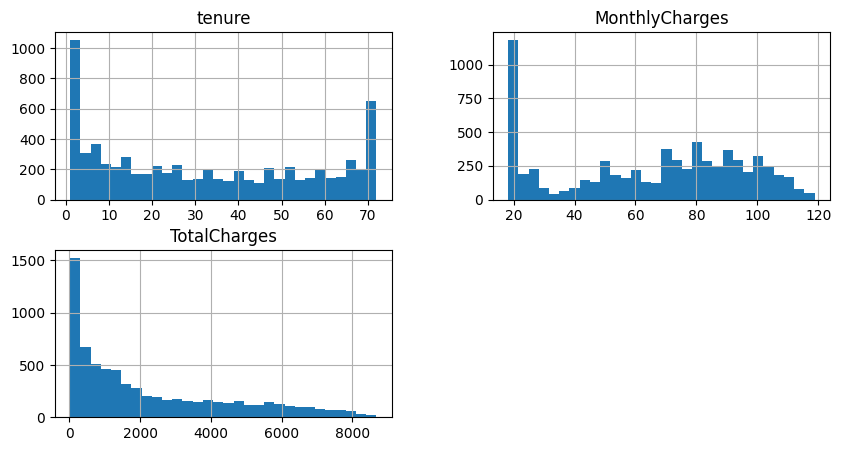

In [33]:
import matplotlib.pyplot as plt
X[["tenure", "MonthlyCharges", "TotalCharges"]].hist(bins=30, figsize=(10,5))
plt.show()

In [35]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
model_3 = GaussianNB()
model_3.fit(X_train, y_train)

GaussianNB()

In [46]:
y_pred_model_1 = model_1.predict(X_test)
y_pred_Model_2 = model_2.predict(X_test)
y_pred_model_3 = model_3.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score,  confusion_matrix, classification_report
print("Model 1 --> LogisticRegression")
print(accuracy_score(y_test, y_pred_model_1))
print(confusion_matrix(y_test, y_pred_model_1))
print(classification_report(y_test, y_pred_model_1))
print("---------------------------------------------")
print("Model 2 --> RandomForestClassifier")
print(accuracy_score(y_test, y_pred_Model_2))
print(confusion_matrix(y_test, y_pred_Model_2))
print(classification_report(y_test, y_pred_Model_2))
print("---------------------------------------------")
print("Model 3 --> NaiveBayes")
print(accuracy_score(y_test, y_pred_model_3))
print(confusion_matrix(y_test, y_pred_model_3))
print(classification_report(y_test, y_pred_model_3))

Model 1 --> LogisticRegression
0.7313432835820896
[[733 300]
 [ 78 296]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

---------------------------------------------
Model 2 --> RandomForestClassifier
0.7590618336886994
[[806 227]
 [112 262]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

---------------------------------------------
Model 3 --> NaiveBayes
0.6574271499644634
[[600 433]
 [ 49 325]]
              precision    recall  f1-s

In [48]:
import joblib
joblib.dump(model_1, "model_1.pkl")
joblib.dump(model_2, "model_2.pkl")
joblib.dump(model_3, "model_3.pkl")

['model_3.pkl']